In [1]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from scipy.stats import norm
from tqdm.auto import tqdm

# Helper functions, colors, etc

In [2]:
def open_dfs(path):
    """Open and concatenate all dataframes in directory."""
    df_list = [pd.read_parquet(f) for f in tqdm(sorted(glob.glob(f"data/{path}/*.pq")), desc=path)]
    return pd.concat(df_list, axis="index")

In [3]:
def penalty(df, grouping_key):
    """Compute flight distance penalty."""
    return df.groupby(grouping_key)[["adsb_dist_in_forecast_pcr", "adsb_dist"]].apply(
        lambda x: x["adsb_dist_in_forecast_pcr"].sum() / x["adsb_dist"].sum()
    )

In [4]:
def hit_rate(df, grouping_key):
    """Compute hit rate."""
    return df.groupby(grouping_key)[["observed_pcr_area_in_forecast_pcr", "observed_pcr_area"]].apply(
        lambda x: x["observed_pcr_area_in_forecast_pcr"].sum() / x["observed_pcr_area"].sum()
    )

In [5]:
def jackknife(df, resampling_key, statistic):
    """Compute jacknife statistics."""
    groups = df.groupby(resampling_key)
    keys = groups.keys.unique()
    indices = groups.indices
    
    jn_list = []
    for drop in tqdm(keys, desc="jackknife"):
        idx = np.concatenate([indices[key] for key in keys if key != drop])
        subset = df.iloc[idx]
        jn_list.append(statistic(subset))

    jn = pd.concat(jn_list, axis="columns")
    return jn

In [6]:
def bootstrap(df, resampling_key, num_iterations, statistic, alpha, rng):
    """Compute bootstrap confidence intervals."""
    groups = df.groupby(resampling_key)
    keys = groups.keys.unique()
    indices = groups.indices
    
    theta_star_list = []
    for i in tqdm(range(num_iterations), desc="bootstrap"):
        samples = rng.choice(keys, keys.size, replace=True)
        idx = np.concatenate([indices[key] for key in samples])
        resampled = df.iloc[idx]
        theta_star_list.append(statistic(resampled))
    
    theta_star = pd.concat(theta_star_list, axis="columns")
    theta = statistic(df)
    z0 = (theta_star < theta.values.reshape((-1,1))).mean(axis="columns").map(norm.ppf)
    jn = jackknife(df, resampling_key, statistic)
    jn_bar = np.mean(jn.values, axis=1, keepdims=True)
    a = ((jn - jn_bar)**3).sum(axis="columns") / (6.0 * ((jn - jn_bar)**2).sum(axis="columns")**1.5)

    z1 = norm.ppf(alpha / 2.0)
    z2 = norm.ppf(1.0 - alpha / 2.0)
    q1 = (z0 + (z0 + z1) / (1.0 - a * (z0 + z1))).apply(norm.cdf)
    q2 = (z0 + (z0 + z2) / (1.0 - a * (z0 + z2))).apply(norm.cdf)
    
    return theta_star.apply(lambda x: x.quantile([q1.loc[x.name], q2.loc[x.name]]).reset_index(drop=True), axis="columns")

In [7]:
exo_black = "#161a26"
tropo_blue = "#1093ff"
solar_orange = "#f26400"
gray50 = "#939598"

# Download processed data

In [92]:
! rm -r data/*

# IAGOS statistics
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/iagos-statistics data/

# Contrails.org (global)
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/contrails-org-adsb data/
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/contrails-org-iagos data/
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/contrails-org-gruan data/

# Contrails.org (CONUS)
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/contrails-org-adsb-contrailwatch-region data/
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/contrails-org-iagos-contrailwatch-region data/
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/contrails-org-gruan-contrailwatch-region data/
! gcloud --no-user-output-enabled storage cp -r gs://contrails-301217-contrail-bench/2025Q1/contrails-org-contrailwatch-contrailwatch-region data/

# Global, January-December 2024

## Contrails.org

#### Final processing + bootstrapping

In [10]:
df_adsb = open_dfs("contrails-org-adsb")
df_iagos = open_dfs("contrails-org-iagos")
df_gruan = open_dfs("contrails-org-gruan")

contrails-org-adsb:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-iagos:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-gruan:   0%|          | 0/8784 [00:00<?, ?it/s]

In [11]:
df = pd.DataFrame({
    "penalty": penalty(df_adsb, "horizontal_buffer"),
    "iagos_hit_rate": hit_rate(df_iagos, "horizontal_buffer"),
    "gruan_hit_rate": hit_rate(df_gruan, "horizontal_buffer"),
})

In [12]:
rng = np.random.default_rng(301217)
n = 1000
penalty_ci = bootstrap(df_adsb, df_adsb["time"].dt.date, n, lambda df: penalty(df, "horizontal_buffer"), 0.05, rng)
iagos_ci = bootstrap(df_iagos, df_iagos["time"].dt.date, n, lambda df: hit_rate(df, "horizontal_buffer"), 0.05, rng)
gruan_ci = bootstrap(df_gruan, df_gruan["time"].dt.date, n, lambda df: hit_rate(df, "horizontal_buffer"), 0.05, rng)

bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/366 [00:00<?, ?it/s]

bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/366 [00:00<?, ?it/s]

bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/366 [00:00<?, ?it/s]

In [13]:
df_ci = pd.DataFrame({
    "penalty_lo": penalty_ci.iloc[:,0],
    "penalty_hi": penalty_ci.iloc[:,1],
    "iagos_hit_rate_lo": iagos_ci.iloc[:,0],
    "iagos_hit_rate_hi": iagos_ci.iloc[:,1],
    "gruan_hit_rate_lo": gruan_ci.iloc[:,0],
    "gruan_hit_rate_hi": gruan_ci.iloc[:,1],
})

In [16]:
df.to_parquet("gs://contrails-301217-contrail-bench/2025Q1/benchmarks/global-contrails-org.pq")

In [17]:
df_ci.to_parquet("gs://contrails-301217-contrail-bench/2025Q1/benchmarks/global-contrails-org-ci.pq")

#### Plot

In [105]:
df = pd.read_parquet("gs://contrails-301217-contrail-bench/2025Q1/benchmarks/global-contrails-org.pq")
df_ci = pd.read_parquet("gs://contrails-301217-contrail-bench/2025Q1/benchmarks/global-contrails-org-ci.pq")
iagos_daily = pd.read_parquet("data/iagos-statistics/daily.pq")
iagos_pcr_rate = iagos_daily["pcr_flight_m"].sum() / iagos_daily["total_flight_m"].sum()

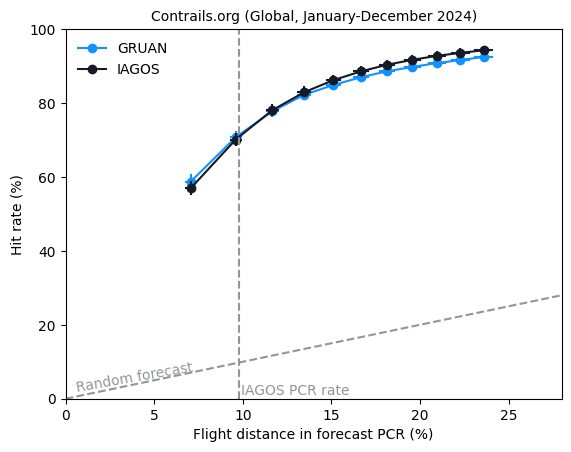

In [106]:
plt.plot(100 * df["penalty"], 100 * df["gruan_hit_rate"], "-o", color=tropo_blue, label="GRUAN")
plt.plot(100 * df_ci[["penalty_lo", "penalty_hi"]].T, 100 * df[["gruan_hit_rate", "gruan_hit_rate"]].T, "-", color=tropo_blue)
plt.plot(100 * df[["penalty", "penalty"]].T, 100 * df_ci[["gruan_hit_rate_lo", "gruan_hit_rate_hi"]].T, "-", color=tropo_blue)

plt.plot(100 * df["penalty"], 100 * df["iagos_hit_rate"], "o-", color=exo_black, label="IAGOS")
plt.plot(100 * df_ci[["penalty_lo", "penalty_hi"]].T, 100 * df[["iagos_hit_rate", "iagos_hit_rate"]].T, "-", color=exo_black)
plt.plot(100 * df[["penalty", "penalty"]].T, 100 * df_ci[["iagos_hit_rate_lo", "iagos_hit_rate_hi"]].T, "-", color=exo_black)

plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Hit rate (%)")
plt.xlim([0, 28])
plt.ylim([0, 100])
plt.gca().axline([0, 0], [100, 100], ls="--", color=gray50)
plt.gca().axvline(x=100 * iagos_pcr_rate, ls="--", color=gray50)
plt.annotate("Random forecast", xy=(0.02, 0.02), xycoords="axes fraction", color=gray50, rotation=10)
plt.annotate("IAGOS PCR rate", xy=(100 * iagos_pcr_rate + 0.1, 1), color=gray50)
plt.legend(loc="upper left", frameon=False)
plt.title("Contrails.org (Global, January-December 2024)", fontsize=10)

plt.savefig("figures/global-contrails-org.pdf", bbox_inches="tight")
plt.savefig("figures/global-contrails-org.png", dpi=300, bbox_inches="tight");

## Google (TODO)

# Global (January/February/December 2024)

## Contrails.org

#### Final processing + bootstrapping

In [26]:
df_adsb = open_dfs("contrails-org-adsb")
df_iagos = open_dfs("contrails-org-iagos")
df_gruan = open_dfs("contrails-org-gruan")

contrails-org-adsb:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-iagos:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-gruan:   0%|          | 0/8784 [00:00<?, ?it/s]

In [32]:
df_adsb = df_adsb.loc[df_adsb["time"].dt.month.isin([1, 2, 12])]
df_iagos = df_iagos.loc[df_iagos["time"].dt.month.isin([1, 2, 12])]
df_gruan = df_gruan.loc[df_gruan["time"].dt.month.isin([1, 2, 12])]

In [33]:
df = pd.DataFrame({
    "penalty": penalty(df_adsb, "horizontal_buffer"),
    "iagos_hit_rate": hit_rate(df_iagos, "horizontal_buffer"),
    "gruan_hit_rate": hit_rate(df_gruan, "horizontal_buffer"),
})

In [34]:
rng = np.random.default_rng(301217)
n = 1000
penalty_ci = bootstrap(df_adsb, df_adsb["time"].dt.date, n, lambda df: penalty(df, "horizontal_buffer"), 0.05, rng)
iagos_ci = bootstrap(df_iagos, df_iagos["time"].dt.date, n, lambda df: hit_rate(df, "horizontal_buffer"), 0.05, rng)
gruan_ci = bootstrap(df_gruan, df_gruan["time"].dt.date, n, lambda df: hit_rate(df, "horizontal_buffer"), 0.05, rng)

bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/91 [00:00<?, ?it/s]

bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/91 [00:00<?, ?it/s]

bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/91 [00:00<?, ?it/s]

In [35]:
df_ci = pd.DataFrame({
    "penalty_lo": penalty_ci.iloc[:,0],
    "penalty_hi": penalty_ci.iloc[:,1],
    "iagos_hit_rate_lo": iagos_ci.iloc[:,0],
    "iagos_hit_rate_hi": iagos_ci.iloc[:,1],
    "gruan_hit_rate_lo": gruan_ci.iloc[:,0],
    "gruan_hit_rate_hi": gruan_ci.iloc[:,1],
})

In [36]:
df.to_parquet("gs://contrails-301217-contrail-bench/2025Q1/benchmarks/global-winter-contrails-org.pq")

In [37]:
df_ci.to_parquet("gs://contrails-301217-contrail-bench/2025Q1/benchmarks/global-winter-contrails-org-ci.pq")

#### Plot

In [78]:
df = pd.read_parquet("gs://contrails-301217-contrail-bench/2025Q1/benchmarks/global-winter-contrails-org.pq")
df_ci = pd.read_parquet("gs://contrails-301217-contrail-bench/2025Q1/benchmarks/global-winter-contrails-org-ci.pq")
iagos_daily = pd.read_parquet("data/iagos-statistics/daily.pq")
iagos_daily = iagos_daily.loc[iagos_daily.index.month.isin([1, 2, 12])]
iagos_pcr_rate = iagos_daily["pcr_flight_m"].sum() / iagos_daily["total_flight_m"].sum()

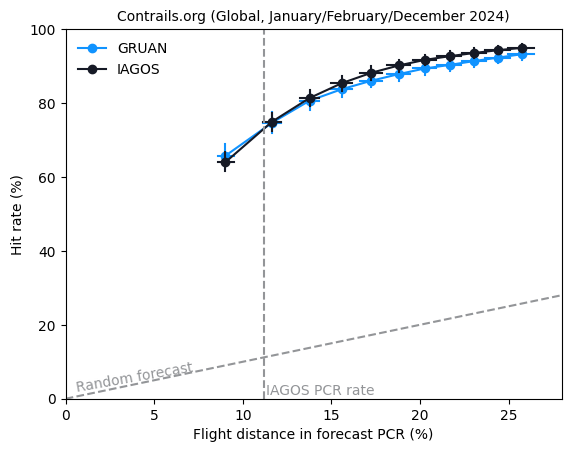

In [79]:
plt.plot(100 * df["penalty"], 100 * df["gruan_hit_rate"], "-o", color=tropo_blue, label="GRUAN")
plt.plot(100 * df_ci[["penalty_lo", "penalty_hi"]].T, 100 * df[["gruan_hit_rate", "gruan_hit_rate"]].T, "-", color=tropo_blue)
plt.plot(100 * df[["penalty", "penalty"]].T, 100 * df_ci[["gruan_hit_rate_lo", "gruan_hit_rate_hi"]].T, "-", color=tropo_blue)

plt.plot(100 * df["penalty"], 100 * df["iagos_hit_rate"], "o-", color=exo_black, label="IAGOS")
plt.plot(100 * df_ci[["penalty_lo", "penalty_hi"]].T, 100 * df[["iagos_hit_rate", "iagos_hit_rate"]].T, "-", color=exo_black)
plt.plot(100 * df[["penalty", "penalty"]].T, 100 * df_ci[["iagos_hit_rate_lo", "iagos_hit_rate_hi"]].T, "-", color=exo_black)

plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Hit rate (%)")
plt.xlim([0, 28])
plt.ylim([0, 100])
plt.gca().axline([0, 0], [100, 100], ls="--", color=gray50)
plt.gca().axvline(x=100 * iagos_pcr_rate, ls="--", color=gray50)
plt.annotate("Random forecast", xy=(0.02, 0.02), xycoords="axes fraction", color=gray50, rotation=10)
plt.annotate("IAGOS PCR rate", xy=(100 * iagos_pcr_rate + 0.1, 1), color=gray50)
plt.legend(loc="upper left", frameon=False)
plt.title("Contrails.org (Global, January/February/December 2024)", fontsize=10)

plt.savefig("figures/global-winter-contrails-org.pdf", bbox_inches="tight")
plt.savefig("figures/global-winter-contrails-org.png", dpi=300, bbox_inches="tight");

## Google (TODO)

# Global (March-May 2024)

## Contrails.org

#### Final processing + bootstrapping

In [49]:
df_adsb = open_dfs("contrails-org-adsb")
df_iagos = open_dfs("contrails-org-iagos")
df_gruan = open_dfs("contrails-org-gruan")

contrails-org-adsb:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-iagos:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-gruan:   0%|          | 0/8784 [00:00<?, ?it/s]

In [50]:
df_adsb = df_adsb.loc[df_adsb["time"].dt.month.between(3, 5)]
df_iagos = df_iagos.loc[df_iagos["time"].dt.month.between(3, 5)]
df_gruan = df_gruan.loc[df_gruan["time"].dt.month.between(3, 5)]

In [51]:
df = pd.DataFrame({
    "penalty": penalty(df_adsb, "horizontal_buffer"),
    "iagos_hit_rate": hit_rate(df_iagos, "horizontal_buffer"),
    "gruan_hit_rate": hit_rate(df_gruan, "horizontal_buffer"),
})

In [52]:
rng = np.random.default_rng(301217)
n = 1000
penalty_ci = bootstrap(df_adsb, df_adsb["time"].dt.date, n, lambda df: penalty(df, "horizontal_buffer"), 0.05, rng)
iagos_ci = bootstrap(df_iagos, df_iagos["time"].dt.date, n, lambda df: hit_rate(df, "horizontal_buffer"), 0.05, rng)
gruan_ci = bootstrap(df_gruan, df_gruan["time"].dt.date, n, lambda df: hit_rate(df, "horizontal_buffer"), 0.05, rng)

bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/92 [00:00<?, ?it/s]

bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/92 [00:00<?, ?it/s]

bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/92 [00:00<?, ?it/s]

In [53]:
df_ci = pd.DataFrame({
    "penalty_lo": penalty_ci.iloc[:,0],
    "penalty_hi": penalty_ci.iloc[:,1],
    "iagos_hit_rate_lo": iagos_ci.iloc[:,0],
    "iagos_hit_rate_hi": iagos_ci.iloc[:,1],
    "gruan_hit_rate_lo": gruan_ci.iloc[:,0],
    "gruan_hit_rate_hi": gruan_ci.iloc[:,1],
})

In [54]:
df.to_parquet("gs://contrails-301217-contrail-bench/2025Q1/benchmarks/global-spring-contrails-org.pq")

In [55]:
df_ci.to_parquet("gs://contrails-301217-contrail-bench/2025Q1/benchmarks/global-spring-contrails-org-ci.pq")

#### Plot

In [75]:
df = pd.read_parquet("gs://contrails-301217-contrail-bench/2025Q1/benchmarks/global-spring-contrails-org.pq")
df_ci = pd.read_parquet("gs://contrails-301217-contrail-bench/2025Q1/benchmarks/global-spring-contrails-org-ci.pq")
iagos_daily = pd.read_parquet("data/iagos-statistics/daily.pq")
iagos_daily = iagos_daily.loc[iagos_daily.index.month.isin([3, 4, 5])]
iagos_pcr_rate = iagos_daily["pcr_flight_m"].sum() / iagos_daily["total_flight_m"].sum()

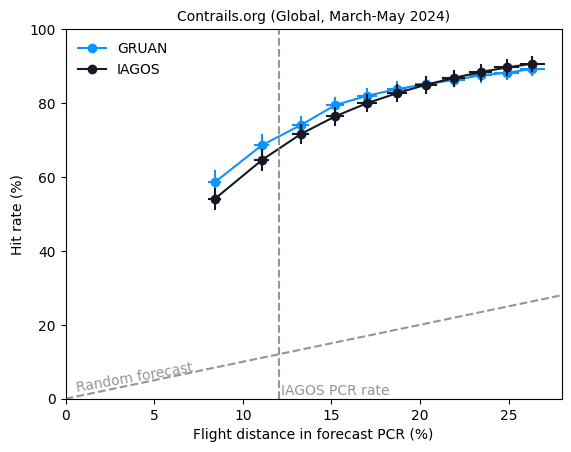

In [77]:
plt.plot(100 * df["penalty"], 100 * df["gruan_hit_rate"], "-o", color=tropo_blue, label="GRUAN")
plt.plot(100 * df_ci[["penalty_lo", "penalty_hi"]].T, 100 * df[["gruan_hit_rate", "gruan_hit_rate"]].T, "-", color=tropo_blue)
plt.plot(100 * df[["penalty", "penalty"]].T, 100 * df_ci[["gruan_hit_rate_lo", "gruan_hit_rate_hi"]].T, "-", color=tropo_blue)

plt.plot(100 * df["penalty"], 100 * df["iagos_hit_rate"], "o-", color=exo_black, label="IAGOS")
plt.plot(100 * df_ci[["penalty_lo", "penalty_hi"]].T, 100 * df[["iagos_hit_rate", "iagos_hit_rate"]].T, "-", color=exo_black)
plt.plot(100 * df[["penalty", "penalty"]].T, 100 * df_ci[["iagos_hit_rate_lo", "iagos_hit_rate_hi"]].T, "-", color=exo_black)

plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Hit rate (%)")
plt.xlim([0, 28])
plt.ylim([0, 100])
plt.gca().axline([0, 0], [100, 100], ls="--", color=gray50)
plt.gca().axvline(x=100 * iagos_pcr_rate, ls="--", color=gray50)
plt.annotate("Random forecast", xy=(0.02, 0.02), xycoords="axes fraction", color=gray50, rotation=10)
plt.annotate("IAGOS PCR rate", xy=(100 * iagos_pcr_rate + 0.1, 1), color=gray50)
plt.legend(loc="upper left", frameon=False)
plt.title("Contrails.org (Global, March-May 2024)", fontsize=10)

plt.savefig("figures/global-spring-contrails-org.pdf", bbox_inches="tight")
plt.savefig("figures/global-spring-contrails-org.png", dpi=300, bbox_inches="tight");

# Global (June-August 2024)

## Contrails.org

#### Final processing + bootstrapping

In [65]:
df_adsb = open_dfs("contrails-org-adsb")
df_iagos = open_dfs("contrails-org-iagos")
df_gruan = open_dfs("contrails-org-gruan")

contrails-org-adsb:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-iagos:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-gruan:   0%|          | 0/8784 [00:00<?, ?it/s]

In [66]:
df_adsb = df_adsb.loc[df_adsb["time"].dt.month.between(6, 8)]
df_iagos = df_iagos.loc[df_iagos["time"].dt.month.between(6, 8)]
df_gruan = df_gruan.loc[df_gruan["time"].dt.month.between(6, 8)]

In [67]:
df = pd.DataFrame({
    "penalty": penalty(df_adsb, "horizontal_buffer"),
    "iagos_hit_rate": hit_rate(df_iagos, "horizontal_buffer"),
    "gruan_hit_rate": hit_rate(df_gruan, "horizontal_buffer"),
})

In [68]:
rng = np.random.default_rng(301217)
n = 1000
penalty_ci = bootstrap(df_adsb, df_adsb["time"].dt.date, n, lambda df: penalty(df, "horizontal_buffer"), 0.05, rng)
iagos_ci = bootstrap(df_iagos, df_iagos["time"].dt.date, n, lambda df: hit_rate(df, "horizontal_buffer"), 0.05, rng)
gruan_ci = bootstrap(df_gruan, df_gruan["time"].dt.date, n, lambda df: hit_rate(df, "horizontal_buffer"), 0.05, rng)

bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/92 [00:00<?, ?it/s]

bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/92 [00:00<?, ?it/s]

bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/92 [00:00<?, ?it/s]

In [69]:
df_ci = pd.DataFrame({
    "penalty_lo": penalty_ci.iloc[:,0],
    "penalty_hi": penalty_ci.iloc[:,1],
    "iagos_hit_rate_lo": iagos_ci.iloc[:,0],
    "iagos_hit_rate_hi": iagos_ci.iloc[:,1],
    "gruan_hit_rate_lo": gruan_ci.iloc[:,0],
    "gruan_hit_rate_hi": gruan_ci.iloc[:,1],
})

In [70]:
df.to_parquet("gs://contrails-301217-contrail-bench/2025Q1/benchmarks/global-summer-contrails-org.pq")

In [71]:
df_ci.to_parquet("gs://contrails-301217-contrail-bench/2025Q1/benchmarks/global-summer-contrails-org-ci.pq")

#### Plot

In [81]:
df = pd.read_parquet("gs://contrails-301217-contrail-bench/2025Q1/benchmarks/global-summer-contrails-org.pq")
df_ci = pd.read_parquet("gs://contrails-301217-contrail-bench/2025Q1/benchmarks/global-summer-contrails-org-ci.pq")
iagos_daily = pd.read_parquet("data/iagos-statistics/daily.pq")
iagos_daily = iagos_daily.loc[iagos_daily.index.month.isin([6, 7, 8])]
iagos_pcr_rate = iagos_daily["pcr_flight_m"].sum() / iagos_daily["total_flight_m"].sum()

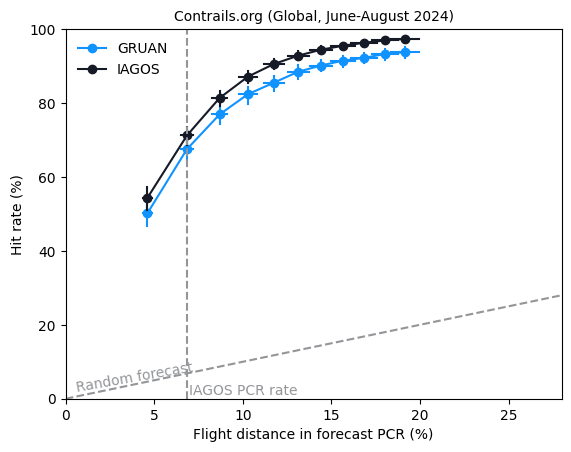

In [82]:
plt.plot(100 * df["penalty"], 100 * df["gruan_hit_rate"], "-o", color=tropo_blue, label="GRUAN")
plt.plot(100 * df_ci[["penalty_lo", "penalty_hi"]].T, 100 * df[["gruan_hit_rate", "gruan_hit_rate"]].T, "-", color=tropo_blue)
plt.plot(100 * df[["penalty", "penalty"]].T, 100 * df_ci[["gruan_hit_rate_lo", "gruan_hit_rate_hi"]].T, "-", color=tropo_blue)

plt.plot(100 * df["penalty"], 100 * df["iagos_hit_rate"], "o-", color=exo_black, label="IAGOS")
plt.plot(100 * df_ci[["penalty_lo", "penalty_hi"]].T, 100 * df[["iagos_hit_rate", "iagos_hit_rate"]].T, "-", color=exo_black)
plt.plot(100 * df[["penalty", "penalty"]].T, 100 * df_ci[["iagos_hit_rate_lo", "iagos_hit_rate_hi"]].T, "-", color=exo_black)

plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Hit rate (%)")
plt.xlim([0, 28])
plt.ylim([0, 100])
plt.gca().axline([0, 0], [100, 100], ls="--", color=gray50)
plt.gca().axvline(x=100 * iagos_pcr_rate, ls="--", color=gray50)
plt.annotate("Random forecast", xy=(0.02, 0.02), xycoords="axes fraction", color=gray50, rotation=10)
plt.annotate("IAGOS PCR rate", xy=(100 * iagos_pcr_rate + 0.1, 1), color=gray50)
plt.legend(loc="upper left", frameon=False)
plt.title("Contrails.org (Global, June-August 2024)", fontsize=10)

plt.savefig("figures/global-summer-contrails-org.pdf", bbox_inches="tight")
plt.savefig("figures/global-summer-contrails-org.png", dpi=300, bbox_inches="tight");

## Google (TODO)

# Global (September-November 2024)

## Contrails.org

#### Final processing + bootstrapping

In [83]:
df_adsb = open_dfs("contrails-org-adsb")
df_iagos = open_dfs("contrails-org-iagos")
df_gruan = open_dfs("contrails-org-gruan")

contrails-org-adsb:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-iagos:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-gruan:   0%|          | 0/8784 [00:00<?, ?it/s]

In [84]:
df_adsb = df_adsb.loc[df_adsb["time"].dt.month.between(9, 11)]
df_iagos = df_iagos.loc[df_iagos["time"].dt.month.between(9, 11)]
df_gruan = df_gruan.loc[df_gruan["time"].dt.month.between(9, 11)]

In [85]:
df = pd.DataFrame({
    "penalty": penalty(df_adsb, "horizontal_buffer"),
    "iagos_hit_rate": hit_rate(df_iagos, "horizontal_buffer"),
    "gruan_hit_rate": hit_rate(df_gruan, "horizontal_buffer"),
})

In [86]:
rng = np.random.default_rng(301217)
n = 1000
penalty_ci = bootstrap(df_adsb, df_adsb["time"].dt.date, n, lambda df: penalty(df, "horizontal_buffer"), 0.05, rng)
iagos_ci = bootstrap(df_iagos, df_iagos["time"].dt.date, n, lambda df: hit_rate(df, "horizontal_buffer"), 0.05, rng)
gruan_ci = bootstrap(df_gruan, df_gruan["time"].dt.date, n, lambda df: hit_rate(df, "horizontal_buffer"), 0.05, rng)

bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/91 [00:00<?, ?it/s]

bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/91 [00:00<?, ?it/s]

bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/91 [00:00<?, ?it/s]

In [87]:
df_ci = pd.DataFrame({
    "penalty_lo": penalty_ci.iloc[:,0],
    "penalty_hi": penalty_ci.iloc[:,1],
    "iagos_hit_rate_lo": iagos_ci.iloc[:,0],
    "iagos_hit_rate_hi": iagos_ci.iloc[:,1],
    "gruan_hit_rate_lo": gruan_ci.iloc[:,0],
    "gruan_hit_rate_hi": gruan_ci.iloc[:,1],
})

In [88]:
df.to_parquet("gs://contrails-301217-contrail-bench/2025Q1/benchmarks/global-autumn-contrails-org.pq")

In [89]:
df_ci.to_parquet("gs://contrails-301217-contrail-bench/2025Q1/benchmarks/global-autumn-contrails-org-ci.pq")

#### Plot

In [90]:
df = pd.read_parquet("gs://contrails-301217-contrail-bench/2025Q1/benchmarks/global-autumn-contrails-org.pq")
df_ci = pd.read_parquet("gs://contrails-301217-contrail-bench/2025Q1/benchmarks/global-autumn-contrails-org-ci.pq")
iagos_daily = pd.read_parquet("data/iagos-statistics/daily.pq")
iagos_daily = iagos_daily.loc[iagos_daily.index.month.isin([9, 10, 11])]
iagos_pcr_rate = iagos_daily["pcr_flight_m"].sum() / iagos_daily["total_flight_m"].sum()

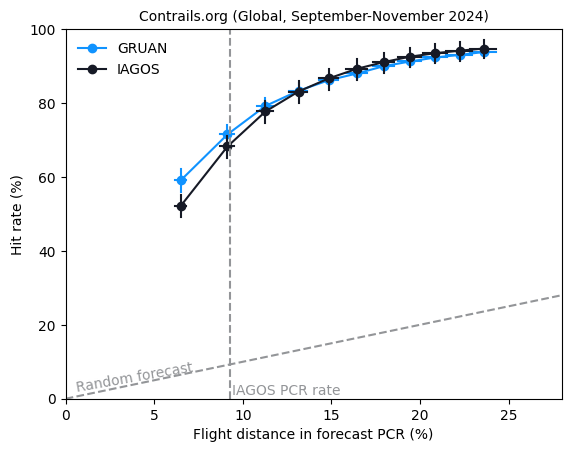

In [91]:
plt.plot(100 * df["penalty"], 100 * df["gruan_hit_rate"], "-o", color=tropo_blue, label="GRUAN")
plt.plot(100 * df_ci[["penalty_lo", "penalty_hi"]].T, 100 * df[["gruan_hit_rate", "gruan_hit_rate"]].T, "-", color=tropo_blue)
plt.plot(100 * df[["penalty", "penalty"]].T, 100 * df_ci[["gruan_hit_rate_lo", "gruan_hit_rate_hi"]].T, "-", color=tropo_blue)

plt.plot(100 * df["penalty"], 100 * df["iagos_hit_rate"], "o-", color=exo_black, label="IAGOS")
plt.plot(100 * df_ci[["penalty_lo", "penalty_hi"]].T, 100 * df[["iagos_hit_rate", "iagos_hit_rate"]].T, "-", color=exo_black)
plt.plot(100 * df[["penalty", "penalty"]].T, 100 * df_ci[["iagos_hit_rate_lo", "iagos_hit_rate_hi"]].T, "-", color=exo_black)

plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Hit rate (%)")
plt.xlim([0, 28])
plt.ylim([0, 100])
plt.gca().axline([0, 0], [100, 100], ls="--", color=gray50)
plt.gca().axvline(x=100 * iagos_pcr_rate, ls="--", color=gray50)
plt.annotate("Random forecast", xy=(0.02, 0.02), xycoords="axes fraction", color=gray50, rotation=10)
plt.annotate("IAGOS PCR rate", xy=(100 * iagos_pcr_rate + 0.1, 1), color=gray50)
plt.legend(loc="upper left", frameon=False)
plt.title("Contrails.org (Global, September-November 2024)", fontsize=10)

plt.savefig("figures/global-autumn-contrails-org.pdf", bbox_inches="tight")
plt.savefig("figures/global-autumn-contrails-org.png", dpi=300, bbox_inches="tight");

## Google (TODO)

# CONUS (January-December 2024)

## Contrails.org

#### Final processing + bootstrapping

In [93]:
df_adsb = open_dfs("contrails-org-adsb-contrailwatch-region")
df_iagos = open_dfs("contrails-org-iagos-contrailwatch-region")
df_gruan = open_dfs("contrails-org-gruan-contrailwatch-region")
df_contrailwatch = open_dfs("contrails-org-contrailwatch-contrailwatch-region")

contrails-org-adsb-contrailwatch-region:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-iagos-contrailwatch-region:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-gruan-contrailwatch-region:   0%|          | 0/8784 [00:00<?, ?it/s]

contrails-org-contrailwatch-contrailwatch-region:   0%|          | 0/8784 [00:00<?, ?it/s]

In [94]:
df = pd.DataFrame({
    "penalty": penalty(df_adsb, "horizontal_buffer"),
    "iagos_hit_rate": hit_rate(df_iagos, "horizontal_buffer"),
    "gruan_hit_rate": hit_rate(df_gruan, "horizontal_buffer"),
    "contrailwatch_hit_rate": hit_rate(df_contrailwatch, "horizontal_buffer"),
})

In [95]:
rng = np.random.default_rng(301217)
n = 1000
penalty_ci = bootstrap(df_adsb, df_adsb["time"].dt.date, n, lambda df: penalty(df, "horizontal_buffer"), 0.05, rng)
iagos_ci = bootstrap(df_iagos, df_iagos["time"].dt.date, n, lambda df: hit_rate(df, "horizontal_buffer"), 0.05, rng)
gruan_ci = bootstrap(df_gruan, df_gruan["time"].dt.date, n, lambda df: hit_rate(df, "horizontal_buffer"), 0.05, rng)
contrailwatch_ci = bootstrap(df_contrailwatch, df_contrailwatch["time"].dt.date, n, lambda df: hit_rate(df, "horizontal_buffer"), 0.05, rng)

bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/366 [00:00<?, ?it/s]

bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/366 [00:00<?, ?it/s]

bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/366 [00:00<?, ?it/s]

bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

jackknife:   0%|          | 0/366 [00:00<?, ?it/s]

In [96]:
df_ci = pd.DataFrame({
    "penalty_lo": penalty_ci.iloc[:,0],
    "penalty_hi": penalty_ci.iloc[:,1],
    "iagos_hit_rate_lo": iagos_ci.iloc[:,0],
    "iagos_hit_rate_hi": iagos_ci.iloc[:,1],
    "gruan_hit_rate_lo": gruan_ci.iloc[:,0],
    "gruan_hit_rate_hi": gruan_ci.iloc[:,1],
    "contrailwatch_hit_rate_lo": contrailwatch_ci.iloc[:,0],
    "contrailwatch_hit_rate_hi": contrailwatch_ci.iloc[:,1],
})

In [97]:
df.to_parquet("gs://contrails-301217-contrail-bench/2025Q1/benchmarks/conus-contrails-org.pq")

In [98]:
df_ci.to_parquet("gs://contrails-301217-contrail-bench/2025Q1/benchmarks/conus-contrails-org-ci.pq")

#### Plot

In [100]:
df = pd.read_parquet("gs://contrails-301217-contrail-bench/2025Q1/benchmarks/conus-contrails-org.pq")
df_ci = pd.read_parquet("gs://contrails-301217-contrail-bench/2025Q1/benchmarks/conus-contrails-org-ci.pq")
iagos_daily = pd.read_parquet("data/iagos-statistics/daily-contrailwatch.pq")
iagos_pcr_rate = iagos_daily["pcr_flight_m"].sum() / iagos_daily["total_flight_m"].sum()

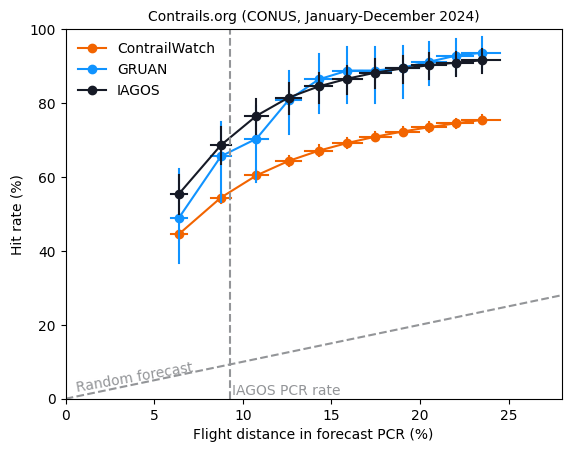

In [102]:
plt.plot(100 * df["penalty"], 100 * df["contrailwatch_hit_rate"], "o-", color=solar_orange, label="ContrailWatch")
plt.plot(100 * df_ci[["penalty_lo", "penalty_hi"]].T, 100 * df[["contrailwatch_hit_rate", "contrailwatch_hit_rate"]].T, "-", color=solar_orange)
plt.plot(100 * df[["penalty", "penalty"]].T, 100 * df_ci[["contrailwatch_hit_rate_lo", "contrailwatch_hit_rate_hi"]].T, "-", color=solar_orange)

plt.plot(100 * df["penalty"], 100 * df["gruan_hit_rate"], "-o", color=tropo_blue, label="GRUAN")
plt.plot(100 * df_ci[["penalty_lo", "penalty_hi"]].T, 100 * df[["gruan_hit_rate", "gruan_hit_rate"]].T, "-", color=tropo_blue)
plt.plot(100 * df[["penalty", "penalty"]].T, 100 * df_ci[["gruan_hit_rate_lo", "gruan_hit_rate_hi"]].T, "-", color=tropo_blue)

plt.plot(100 * df["penalty"], 100 * df["iagos_hit_rate"], "o-", color=exo_black, label="IAGOS")
plt.plot(100 * df_ci[["penalty_lo", "penalty_hi"]].T, 100 * df[["iagos_hit_rate", "iagos_hit_rate"]].T, "-", color=exo_black)
plt.plot(100 * df[["penalty", "penalty"]].T, 100 * df_ci[["iagos_hit_rate_lo", "iagos_hit_rate_hi"]].T, "-", color=exo_black)

plt.xlabel("Flight distance in forecast PCR (%)")
plt.ylabel("Hit rate (%)")
plt.xlim([0, 28])
plt.ylim([0, 100])
plt.gca().axline([0, 0], [100, 100], ls="--", color=gray50)
plt.gca().axvline(x=100 * iagos_pcr_rate, ls="--", color=gray50)
plt.annotate("Random forecast", xy=(0.02, 0.02), xycoords="axes fraction", color=gray50, rotation=10)
plt.annotate("IAGOS PCR rate", xy=(100 * iagos_pcr_rate + 0.1, 1), color=gray50)
plt.legend(loc="upper left", frameon=False)
plt.title("Contrails.org (CONUS, January-December 2024)", fontsize=10)

plt.savefig("figures/conus-contrails-org.pdf", bbox_inches="tight")
plt.savefig("figures/conus-contrails-org.png", dpi=300, bbox_inches="tight");

## Google (TODO)